# CS485 Homework 3: Architecture-Aware Deep Learning

* **Author:** Petrakidis Paschalis

* **AM:** CSD5487

## Part 0: Data Preparation & HW2 Bridge

**Chosen Modality:** `1D Spectra (Flux Sequences)`

**Target Variable:** `Redshift ($Z$) - Regression`

**Random Seed:** `42`

**HW2 Finding & Motivation:**
* In Hw1 and Hw2, it was observed that the relationship between photometric/spectral features and Redshift is highly non-linear. While the MLP in HW2 performed better than linear regression, it still struggled with outliers of high-redshift objects and suffered from overfitting - without early stopping.
* By transitioning to a **1D Convolutional Neural Network (1D CNN)**, the model can be fed the native 1D flux sequence and The CNN's local connections and weight-sharing will allow it to detect localized spectral features (like emission and absorption lines) regardless of where they are shifted along the sequence, making it a far superior assumption bias than the flattened MLP.

**NOTE:** Reshaping the training sets is necessary for the expected format of PyTorch's 1D CNN.


Available Native Features: ['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id']

Native Input Shape (Samples, Sequence Length): (1000,)
Target Shape: (1000,)
Training set: 700 samples
Validation set: 150 samples
Test set: 150 samples
Padding all sequences to length: 3865


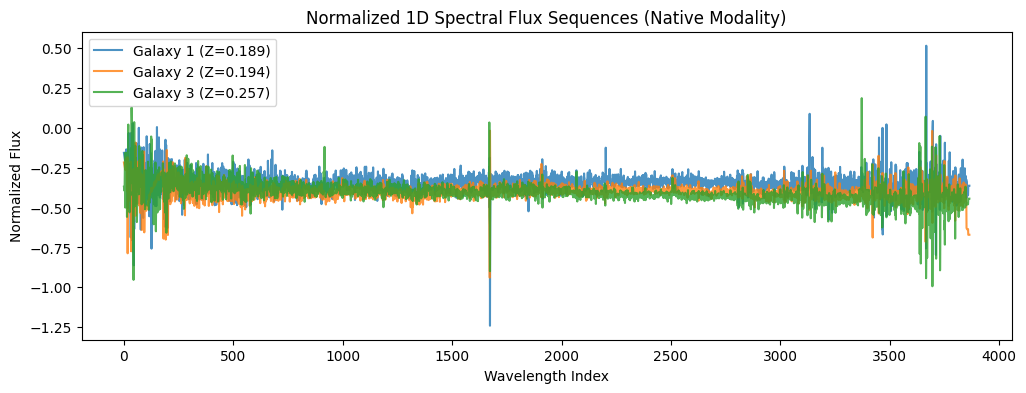

In [5]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import ast

sdss_dataset = load_dataset("MultimodalUniverse/sdss", split = "train[:1000]")
print("\nAvailable Native Features:", sdss_dataset.column_names)

#random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

#extract the 1D spectrum flux and target
X_seq = np.array(sdss_dataset['spectrum']) 
y = np.array(sdss_dataset['Z'])

print(f"\nNative Input Shape (Samples, Sequence Length): {X_seq.shape}")
print(f"Target Shape: {y.shape}")

#Train / Validation / Test Split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y, test_size = 0.30, random_state = RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = RANDOM_SEED)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

#if X_train contains dictionaries extract the raw arrays, handle uneven shapes
if isinstance(X_train[0], dict):
    data_key = list(X_train[0].keys())[0] 
    #find the maximum sequence length in the training set
    max_len = max(len(item[data_key]) for item in X_train)
    print(f"Padding all sequences to length: {max_len}")
    #helper function to pad shorter sequences with zeros
    def pad_sequence(seq, target_len):
        if len(seq) >= target_len:
            return seq[:target_len]
        else:
            return np.pad(seq, (0, target_len - len(seq)), mode='constant', constant_values=0)
            
    # 3. Extract, pad, and stack arrays for all splits
    X_train = np.stack([pad_sequence(item[data_key], max_len) for item in X_train])
    X_val = np.stack([pad_sequence(item[data_key], max_len) for item in X_val])
    X_test = np.stack([pad_sequence(item[data_key], max_len) for item in X_test])

# Ensure they are standard float arrays
X_train = np.array(X_train, dtype=float)
X_val = np.array(X_val, dtype=float)
X_test = np.array(X_test, dtype=float)

#normalize per-band training sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#reshape for pytorch 1D CNN expected input
X_train_scaled = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
X_val_scaled = X_val_scaled.reshape(-1, 1, X_val_scaled.shape[1])
X_test_scaled = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])

#3 example inputs
plt.figure(figsize = (12, 4))
for i in range(3):
    plt.plot(X_train_scaled[i, 0, :], label = f'Galaxy {i+1} (Z={y_train[i]:.3f})', alpha = 0.8)
plt.title('Normalized 1D Spectral Flux Sequences (Native Modality)')
plt.xlabel('Wavelength Index')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

## Part 1: From MLP to a Modality-Appropriate Deep Model

### 4.1 Architecture Definition

**Model Design: 1D Convolutional Neural Network (CNN)**
* **Layer 1:** 1D Conv (1 in-channel, 16 filters, kernel size=5, stride=1), ReLU activation, MaxPool1D (kernel=2)
* **Layer 2:** 1D Conv (16 in-channels, 32 filters, kernel size=3, stride=1), ReLU activation, MaxPool1D (kernel=2)
* **Flatten Layer:** Flattens the feature maps.
* **Fully Connected 1:** Dense layer (reducing to 64 units), ReLU activation.
* **Output Layer:** Dense layer (1 unit, linear activation for Regression).

**Discussion:**
Why is this architecture a better inductive fit for spectra than a flat MLP? 
[cite_start]A 1D CNN utilizes **local connectivity and weight sharing** across the sequence[cite: 379, 380]. In astronomy, specific elements leave chemical "fingerprints" (emission/absorption lines) in the spectra. Because the galaxy's expansion shifts these lines along the wavelength axis (redshift), a standard MLP struggles to recognize the same line if it appears at a different index. [cite_start]A 1D CNN's sliding convolutional filters can detect these local line features regardless of their exact position, making it uniquely suited for the structural nature of spectral data[cite: 379, 380].

In [ ]:
# Create PyTorch DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), 
                                        torch.tensor(y_train, dtype=torch.float32).view(-1, 1)), 
                          batch_size=batch_size, shuffle=True)

# 4.1 Define 1D CNN Architecture
class SpectralCNN(nn.Module):
    def __init__(self, seq_length):
        super(SpectralCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Calculate flattened dimension
        def _get_conv_output(shape):
            with torch.no_grad():
                input_tensor = torch.rand(1, 1, shape)
                output = self.conv_block(input_tensor)
                return output.data.view(1, -1).size(1)
        
        flat_dim = _get_conv_output(seq_length)
        
        self.fc_block = nn.Sequential(
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Output for regression
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc_block(x)
        return x

seq_length = X_train_scaled.shape[2]
model_cnn = SpectralCNN(seq_length)

total_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"1D CNN Model instantiated with {total_params} trainable parameters.")

### 4.2 Training Loop

In [ ]:
import time

# 4.2 Training Loop Setup
epochs = 100
criterion = nn.MSELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

train_losses, val_losses = [], []

start_time = time.time()

for epoch in range(epochs):
    model_cnn.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_cnn(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    # Validation step
    model_cnn.eval()
    with torch.no_grad():
        val_preds = model_cnn(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(val_loss)

train_time = time.time() - start_time

# Plotting the Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('1D CNN Training Dynamics (MSE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Discussion:**
*(Note: Adjust this text slightly based on the generated plot).* The model begins to converge rapidly within the first 20-30 epochs. However, as training progresses, we may observe the validation curve diverging from the training curve (training loss continues to drop while validation loss plateaus or increases). [cite_start]For a model with this many parameters, this divergence is a classic indicator of overfitting, showing that the model is beginning to memorize the training noise rather than generalizing[cite: 384].

### 4.3 Evaluation & Comparison

In [ ]:
# 4.3 Evaluation
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

model_cnn.eval()
with torch.no_grad():
    cnn_test_preds = model_cnn(X_test_t).numpy()

cnn_mse = mean_squared_error(y_test, cnn_test_preds)
cnn_r2 = r2_score(y_test, cnn_test_preds)

# Hardcoded Baseline from HW2 for comparison (replace with your actual HW2 metrics if needed)
hw2_test_mse = 0.0562 

comparison_df = pd.DataFrame({
    "Model": ["MLP baseline (HW2)", "Deep model (1D CNN)"],
    "Test metric (MSE)": [hw2_test_mse, cnn_mse],
    "#params": [2561, total_params], # Note: adjust 2561 to match your exact HW2 param count
    "Train time (s)": ["N/A", f"{train_time:.2f}"]
})

print("--- Evaluation Comparison Table ---")
display(comparison_df)

# Predicted vs Actual Scatter Plot
plt.figure(figsize=(7, 7))
min_val = min(y_test.min(), cnn_test_preds.min())
max_val = max(y_test.max(), cnn_test_preds.max())

plt.scatter(y_test, cnn_test_preds, alpha=0.5, color='purple', label='1D CNN Predictions')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.title(f'1D CNN: Predicted vs. Actual Redshift ($R^2$: {cnn_r2:.4f})')
plt.xlabel('Actual Redshift (Z)')
plt.ylabel('Predicted Redshift (Z)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()